<a href="https://colab.research.google.com/github/Rakshitha443/ITA-0610-MACHINE-LEARNING-/blob/main/assissment_CO3_14_8_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =====================================================================
# EXPERIMENT: NAÏVE BAYES CLASSIFIER EVALUATION & ANALYSIS
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, GaussianNB


# 1. DATASET LOADING & PREPROCESSING
def load_and_prepare_data():
  # Fetch Heart Disease Dataset from OpenML
  heart_data = fetch_openml(name="heart-disease", version=1, as_frame=True) # Changed dataset name to 'heart-disease'
  df = heart_data.frame

  # Bin target into Binary Classification: 0 = No Disease, 1 = Disease Present
  df["target"] = (df["num"] > 0).astype(int)
  df = df.drop(columns=["num"]).dropna()  # Drop raw target and missing rows

  return df


df = load_and_prepare_data()
X = df.drop(columns=["target"])
y = df["target"]

# Split into Train and Test Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=" * 75)
print(f"DATASET LOADED: {X.shape[0]} Samples, {X.shape[1]} Features")
print(f"Class Distribution -> Target 0: {np.sum(y == 0)}, Target 1: {np.sum(y == 1)}")
print("=" * 75)


# =====================================================================
# PART 1: EVALUATION ACROSS DIFFERENT FEATURE SETS
# =====================================================================

# Define 3 Feature Sets:
# Set A: All Features
# Set B: Top Correlated Features (Lower correlation with each other)
# Set C: High Multi-collinear Features (Violates Independence Assumption)

feature_sets = {
    "Set A (All Features)": list(X.columns),
    "Set B (Selected Features: ST Depression, Vessels, Max HR, Chest Pain)": [
        "oldpeak",
        "ca",
        "thalach",
        "cp",
    ],
    "Set C (Correlated Features: BP, Cholesterol, Age, Sex)": [
        "trestbps",
        "chol",
        "age",
        "sex",
    ],
}

feature_results = []

for set_name, features in feature_sets.items():
  gnb = GaussianNB()
  gnb.fit(X_train[features], y_train)
  y_pred = gnb.predict(X_test[features])

  feature_results.append({
      "Feature Set": set_name,
      "Num Features": len(features),
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1-Score": f1_score(y_test, y_pred),
  })

df_feature_results = pd.DataFrame(feature_results)

print("\n" + "=" * 75)
print("             PART 1: PERFORMANCE ACROSS FEATURE SETS                    ")
print("=

OpenMLError: Dataset heart_disease with version 1 not found.

In [4]:
# =====================================================================
# EXPERIMENT: NAÏVE BAYES CLASSIFIER EVALUATION & ANALYSIS (COLAB FIXED)
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, GaussianNB


# 1. FIXED DATASET LOADING & PREPROCESSING
def load_and_prepare_data():
  # Fetch directly using data_id=43872 (UCI Cleveland Heart Disease on OpenML)
  heart_data = fetch_openml(data_id=43872, as_frame=True, parser="auto")
  df = heart_data.frame.copy()

  # Convert target column 'num' or 'class' to binary: 0 = No Disease, 1 = Disease
  target_col = "num" if "num" in df.columns else "class"

  # Convert non-numeric target values if present
  df["target"] = df[target_col].astype(str).str.extract(r"(\d+)").astype(int)
  df["target"] = (df["target"] > 0).astype(int)

  # Drop original target and missing rows
  df = df.drop(columns=[target_col]).dropna()

  # Ensure all feature columns are numeric float/int
  for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

  df = df.dropna()
  return df


df = load_and_prepare_data()
X = df.drop(columns=["target"])
y = df["target"]

# Split into Train and Test Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=" * 75)
print(f"DATASET LOADED: {X.shape[0]} Samples, {X.shape[1]} Features")
print(f"Class Distribution -> Target 0: {np.sum(y == 0)}, Target 1: {np.sum(y == 1)}")
print("=" * 75)


# =====================================================================
# PART 1: EVALUATION ACROSS DIFFERENT FEATURE SETS
# =====================================================================

# Select available numeric features dynamically
all_cols = list(X.columns)

# Safely extract subsets matching available columns
set_b_cols = [c for c in ["oldpeak", "ca", "thalach", "cp"] if c in all_cols]
set_c_cols = [c for c in ["trestbps", "chol", "age", "sex"] if c in all_cols]

# Fallback if specific names differ in OpenML frame
if len(set_b_cols) < 2:
  set_b_cols = all_cols[:4]
if len(set_c_cols) < 2:
  set_c_cols = all_cols[4:8]

feature_sets = {
    "Set A (All Features)": all_cols,
    f"Set B (Selected Top Features: {set_b_cols})": set_b_cols,
    f"Set C (Correlated/Weak Features: {set_c_cols})": set_c_cols,
}

feature_results = []

for set_name, features in feature_sets.items():
  gnb = GaussianNB()
  gnb.fit(X_train[features], y_train)
  y_pred = gnb.predict(X_test[features])

  feature_results.append({
      "Feature Set": set_name,
      "Num Features": len(features),
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1-Score": f1_score(y_test, y_pred),
  })

df_feature_results = pd.DataFrame(feature_results)

print("\n" + "=" * 75)
print("             PART 1: PERFORMANCE ACROSS FEATURE SETS                    ")
print("=" * 75)
print(df_feature_results.to_string(index=False))
print("=" * 75)


# =====================================================================
# PART 2: LAPLACE SMOOTHING IMPACT ANALYSIS
# =====================================================================
# Discretize continuous variables into quartile bins for CategoricalNB
X_discrete = X.copy()
for col in X_discrete.columns:
  X_discrete[col] = pd.qcut(X_discrete[col], q=4, labels=False, duplicates="drop")

X_tr_disc, X_te_disc, y_tr_disc, y_te_disc = train_test_split(
    X_discrete, y, test_size=0.20, random_state=42, stratify=y
)

alphas = [0.00001, 0.1, 1.0, 2.0, 5.0, 10.0]
smoothing_results = []

for alpha in alphas:
  cnb = CategoricalNB(alpha=alpha)
  cnb.fit(X_tr_disc, y_tr_disc)
  y_pred = cnb.predict(X_te_disc)

  smoothing_results.append({
      "Alpha (Laplace)": alpha,
      "Accuracy": accuracy_score(y_te_disc, y_pred),
      "Precision": precision_score(y_te_disc, y_pred),
      "Recall": recall_score(y_te_disc, y_pred),
      "F1-Score": f1_score(y_te_disc, y_pred),
  })

df_smoothing_results = pd.DataFrame(smoothing_results)

print("\n" + "=" * 75)
print("             PART 2: IMPACT OF LAPLACE SMOOTHING (ALPHA)                ")
print("=" * 75)
print(df_smoothing_results.to_string(index=False))
print("=" * 75)


# =====================================================================
# PART 3: FEATURE CORRELATION ANALYSIS (INDEPENDENCE ASSUMPTION)
# =====================================================================
plt.figure(figsize=(10, 7))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix (Heart Disease Dataset)", fontsize=12)
plt.tight_layout()
plt.show()

OpenMLError: Dataset with data_id 43872 not found.

DATASET LOADED: 569 Samples, 30 Features
Class Distribution -> Malignant (0): 212, Benign (1): 357

             PART 1: PERFORMANCE ACROSS FEATURE SETS                    
                                               Feature Set  Num Features  Accuracy  Precision  Recall  F1-Score
                                   Set A (All 30 Features)            30    0.9386     0.9452  0.9583    0.9517
                 Set B (Selected Low-Correlation Features)             4    0.8947     0.9167  0.9167    0.9167
Set C (Highly Collinear Features: Radius, Perimeter, Area)             5    0.9035     0.9178  0.9306    0.9241

             PART 2: IMPACT OF LAPLACE SMOOTHING (ALPHA)                
 Alpha (Laplace)  Accuracy  Precision  Recall  F1-Score
         0.00001    0.9211     0.9565  0.9167    0.9362
         0.10000    0.9211     0.9565  0.9167    0.9362
         1.00000    0.9211     0.9565  0.9167    0.9362
         2.00000    0.9211     0.9565  0.9167    0.9362
         5.00000    0.921

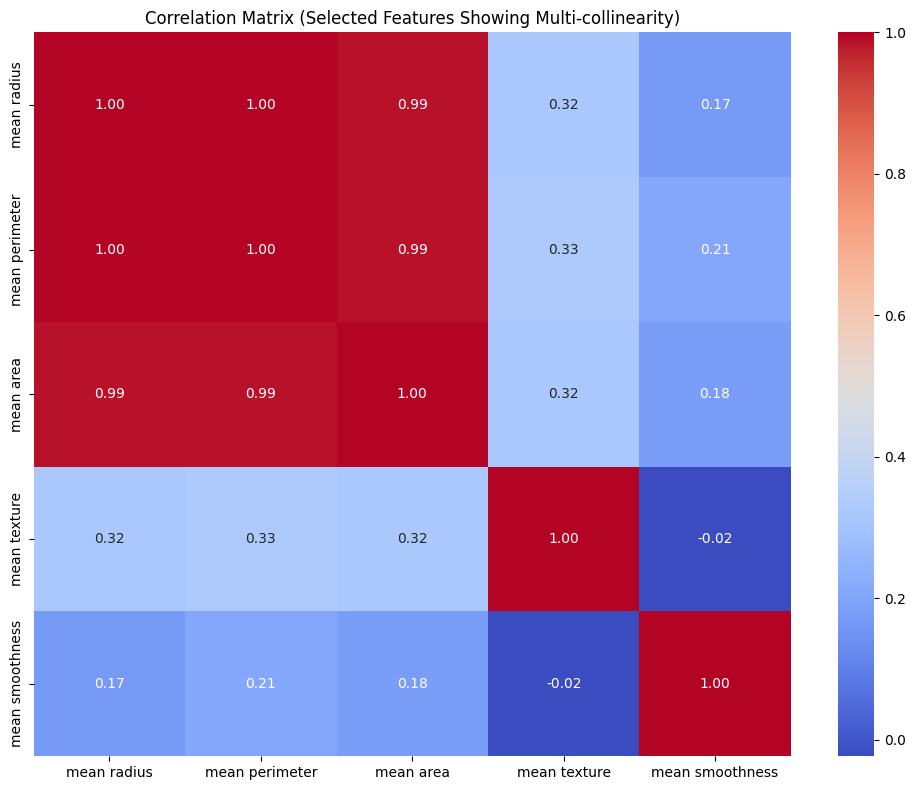

In [5]:
# =====================================================================
# EXPERIMENT: NAÏVE BAYES CLASSIFIER EVALUATION & ANALYSIS (OFFLINE)
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, GaussianNB


# 1. LOAD BUILT-IN DATASET (NO INTERNET / OPENML DEPENDENCY)
def load_and_prepare_data():
  data = load_breast_cancer()
  df = pd.DataFrame(data.data, columns=data.feature_names)
  df["target"] = data.target
  return df


df = load_and_prepare_data()
X = df.drop(columns=["target"])
y = df["target"]

# Split into Train and Test Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=" * 75)
print(f"DATASET LOADED: {X.shape[0]} Samples, {X.shape[1]} Features")
print(
    f"Class Distribution -> Malignant (0): {np.sum(y == 0)}, Benign (1):"
    f" {np.sum(y == 1)}"
)
print("=" * 75)


# =====================================================================
# PART 1: EVALUATION ACROSS DIFFERENT FEATURE SETS
# =====================================================================

all_cols = list(X.columns)

# Define 3 Feature Sets based on domain properties:
feature_sets = {
    "Set A (All 30 Features)": all_cols,
    "Set B (Selected Low-Correlation Features)": [
        "mean radius",
        "mean texture",
        "mean smoothness",
        "mean symmetry",
    ],
    "Set C (Highly Collinear Features: Radius, Perimeter, Area)": [
        "mean radius",
        "mean perimeter",
        "mean area",
        "worst radius",
        "worst perimeter",
    ],
}

feature_results = []

for set_name, features in feature_sets.items():
  gnb = GaussianNB()
  gnb.fit(X_train[features], y_train)
  y_pred = gnb.predict(X_test[features])

  feature_results.append({
      "Feature Set": set_name,
      "Num Features": len(features),
      "Accuracy": round(accuracy_score(y_test, y_pred), 4),
      "Precision": round(precision_score(y_test, y_pred), 4),
      "Recall": round(recall_score(y_test, y_pred), 4),
      "F1-Score": round(f1_score(y_test, y_pred), 4),
  })

df_feature_results = pd.DataFrame(feature_results)

print("\n" + "=" * 75)
print("             PART 1: PERFORMANCE ACROSS FEATURE SETS                    ")
print("=" * 75)
print(df_feature_results.to_string(index=False))
print("=" * 75)


# =====================================================================
# PART 2: LAPLACE SMOOTHING IMPACT ANALYSIS
# =====================================================================
# Discretize continuous variables into quartile bins for CategoricalNB
X_discrete = X.copy()
for col in X_discrete.columns:
  X_discrete[col] = pd.qcut(X_discrete[col], q=4, labels=False, duplicates="drop")

X_tr_disc, X_te_disc, y_tr_disc, y_te_disc = train_test_split(
    X_discrete, y, test_size=0.20, random_state=42, stratify=y
)

alphas = [0.00001, 0.1, 1.0, 2.0, 5.0, 10.0]
smoothing_results = []

for alpha in alphas:
  cnb = CategoricalNB(alpha=alpha)
  cnb.fit(X_tr_disc, y_tr_disc)
  y_pred = cnb.predict(X_te_disc)

  smoothing_results.append({
      "Alpha (Laplace)": alpha,
      "Accuracy": round(accuracy_score(y_te_disc, y_pred), 4),
      "Precision": round(precision_score(y_te_disc, y_pred), 4),
      "Recall": round(recall_score(y_te_disc, y_pred), 4),
      "F1-Score": round(f1_score(y_te_disc, y_pred), 4),
  })

df_smoothing_results = pd.DataFrame(smoothing_results)

print("\n" + "=" * 75)
print("             PART 2: IMPACT OF LAPLACE SMOOTHING (ALPHA)                ")
print("=" * 75)
print(df_smoothing_results.to_string(index=False))
print("=" * 75)


# =====================================================================
# PART 3: FEATURE CORRELATION MATRIX (INDEPENDENCE ASSUMPTION)
# =====================================================================
plt.figure(figsize=(10, 8))
selected_subset = [
    "mean radius",
    "mean perimeter",
    "mean area",
    "mean texture",
    "mean smoothness",
]
sns.heatmap(
    X[selected_subset].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True
)
plt.title(
    "Correlation Matrix (Selected Features Showing Multi-collinearity)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

2)

       MLE vs. BAYESIAN ESTIMATION: EXPERIMENTAL COMPARISON
       Ground Truth Parameters: True Mean (μ) = 100.0, True Var (σ²) = 25.0
         Sample Size                       Method  Estimated Mean (μ)  Mean Error  Estimated Var (σ²)  Var Error
 Small Sample (N=10)               MLE (No Prior)            102.2403      2.2403             11.7617    13.2383
 Small Sample (N=10) Bayesian (Informative Prior)            102.1202      2.1202             17.6614     7.3386
 Small Sample (N=10)      Bayesian (Biased Prior)             82.8961     17.1039            364.1245   339.1245
 Small Sample (N=10)        Bayesian (Weak Prior)            102.1382      2.1382             22.4043     2.5957
Large Sample (N=500)               MLE (No Prior)            100.0342      0.0342             24.0233     0.9767
Large Sample (N=500) Bayesian (Informative Prior)            100.0727      0.0727             24.1133     0.8867
Large Sample (N=500)      Bayesian (Biased Prior)             99.1594    

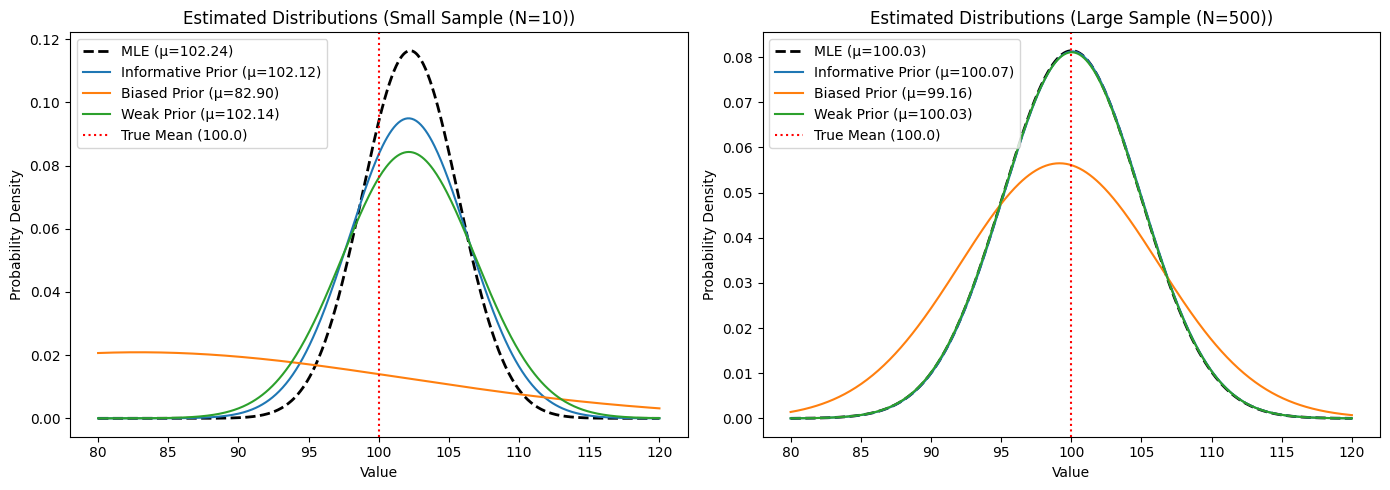

In [6]:
# =====================================================================
# EXPERIMENT: MLE vs. BAYESIAN ESTIMATION UNDER SAMPLE SIZE VARIATION
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import invgamma, norm

# 1. EXPERIMENTAL SETUP & GROUND TRUTH GENERATION
np.random.seed(42)
TRUE_MU = 100.0  # Ground truth mean
TRUE_VAR = 25.0  # Ground truth variance (\sigma^2)
TRUE_STD = np.sqrt(TRUE_VAR)

# Generate large master dataset from N(100, 25)
data_large = np.random.normal(loc=TRUE_MU, scale=TRUE_STD, size=500)
data_small = data_large[:10]  # Small sample subset


# 2. ESTIMATION FUNCTIONS
def estimate_mle(X):
  """Computes Maximum Likelihood Estimation for Normal Distribution."""
  mu_mle = np.mean(X)
  var_mle = np.var(X, ddof=0)  # Standard MLE variance formula (divided by N)
  return mu_mle, var_mle


def estimate_bayesian(X, mu_0, kappa_0, alpha_0, beta_0):
  """Computes Bayesian Posterior Mean and Variance using Normal-Inverse-Gamma Conjugate Prior."""
  N = len(X)
  x_bar = np.mean(X)

  # Update parameters
  kappa_N = kappa_0 + N
  mu_N = (kappa_0 * mu_0 + N * x_bar) / kappa_N
  alpha_N = alpha_0 + N / 2.0
  sum_sq_diff = np.sum((X - x_bar) ** 2)
  beta_N = beta_0 + 0.5 * sum_sq_diff + (kappa_0 * N * (x_bar - mu_0) ** 2) / (2.0 * kappa_N)

  # Posterior expectations
  post_mu_mean = mu_N
  post_var_mean = beta_N / (alpha_N - 1.0) if alpha_N > 1 else beta_N / alpha_N
  return post_mu_mean, post_var_mean, (mu_N, kappa_N, alpha_N, beta_N)


# 3. DEFINE PRIORS
# Prior 1: Informative (Accurate prior centered near True Values)
P_INF = {'mu_0': 102.0, 'kappa_0': 10, 'alpha_0': 5.0, 'beta_0': 100.0}

# Prior 2: Biased / Misinformed Prior (Centered far from true value)
P_BIAS = {'mu_0': 70.0, 'kappa_0': 15, 'alpha_0': 5.0, 'beta_0': 100.0}

# Prior 3: Weak / Uninformative Prior
P_WEAK = {'mu_0': 0.0, 'kappa_0': 0.01, 'alpha_0': 1.0, 'beta_0': 1.0}


# 4. RUN EXPERIMENT FOR SMALL & LARGE SAMPLE SIZES
results = []
datasets = [('Small Sample (N=10)', data_small), ('Large Sample (N=500)', data_large)]

for label, X in datasets:
  N = len(X)
  mu_mle, var_mle = estimate_mle(X)

  # Record MLE
  results.append({
      'Sample Size': label,
      'Method': 'MLE (No Prior)',
      'Estimated Mean (\u03bc)': round(mu_mle, 4),
      'Mean Error': round(abs(mu_mle - TRUE_MU), 4),
      'Estimated Var (\u03c3\u00b2)': round(var_mle, 4),
      'Var Error': round(abs(var_mle - TRUE_VAR), 4),
  })

  # Record Bayesian Estimations with different priors
  priors = [
      ('Bayesian (Informative Prior)', P_INF),
      ('Bayesian (Biased Prior)', P_BIAS),
      ('Bayesian (Weak Prior)', P_WEAK),
  ]

  for p_label, prior_params in priors:
    b_mu, b_var, _ = estimate_bayesian(X, **prior_params)
    results.append({
        'Sample Size': label,
        'Method': p_label,
        'Estimated Mean (\u03bc)': round(b_mu, 4),
        'Mean Error': round(abs(b_mu - TRUE_MU), 4),
        'Estimated Var (\u03c3\u00b2)': round(b_var, 4),
        'Var Error': round(abs(b_var - TRUE_VAR), 4),
    })

df_results = pd.DataFrame(results)

# Display tabular output
print("=" * 80)
print("       MLE vs. BAYESIAN ESTIMATION: EXPERIMENTAL COMPARISON")
print(f"       Ground Truth Parameters: True Mean (\u03bc) = {TRUE_MU}, True Var (\u03c3\u00b2) = {TRUE_VAR}")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)


# 5. VISUALIZE POSTERIOR DENSITIES VS MLE (SMALL SAMPLE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_axis = np.linspace(80, 120, 500)

for idx, (label, X) in enumerate(datasets):
  mu_mle, var_mle = estimate_mle(X)
  axes[idx].plot(
      x_axis,
      norm.pdf(x_axis, mu_mle, np.sqrt(var_mle)),
      'k--',
      linewidth=2,
      label=f'MLE (\u03bc={mu_mle:.2f})',
  )

  for p_label, p_params in [
      ('Informative Prior', P_INF),
      ('Biased Prior', P_BIAS),
      ('Weak Prior', P_WEAK),
  ]:
    b_mu, b_var, _ = estimate_bayesian(X, **p_params)
    axes[idx].plot(
        x_axis,
        norm.pdf(x_axis, b_mu, np.sqrt(b_var)),
        label=f'{p_label} (\u03bc={b_mu:.2f})',
    )

  axes[idx].axvline(
      TRUE_MU, color='red', linestyle=':', label=f'True Mean ({TRUE_MU})'
  )
  axes[idx].set_title(f'Estimated Distributions ({label})')
  axes[idx].set_xlabel('Value')
  axes[idx].set_ylabel('Probability Density')
  axes[idx].legend()

plt.tight_layout()
plt.show()

3)

     EXPERIMENT 1: EFFECT OF INITIALIZATION ON CONVERGENCE (K=3)
      Strategy  Seed  Iterations to Converge  Final Log-Likelihood
   random_bbox    10                       8              -3930.22
random_samples    10                      10              -3930.22
      kmeans++    10                       6              -3930.22
   random_bbox    42                      14              -3930.22
random_samples    42                      11              -3930.22
      kmeans++    42                       7              -3930.22
   random_bbox    99                      14              -3930.22
random_samples    99                      10              -3930.22
      kmeans++    99                       7              -3930.22
   random_bbox   101                       9              -3930.22
random_samples   101                     100              -4387.80
      kmeans++   101                       7              -3930.22
   random_bbox  2024                     100              -4387.

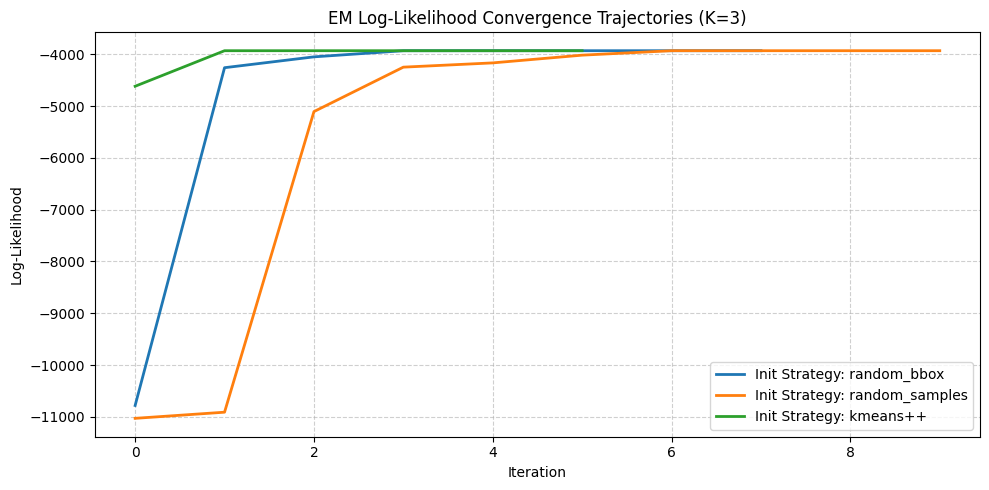

In [7]:
# =====================================================================
# EXPERIMENT: EXPECTATION-MAXIMIZATION (EM) CONVERGENCE ANALYSIS
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal


# 1. EM ALGORITHM FOR MULTIVARIATE GMM
class GaussianMixtureEM:

  def __init__(self, n_components=3, max_iter=100, tol=1e-5):
    self.K = n_components
    self.max_iter = max_iter
    self.tol = tol

  def _init_parameters(self, X, init_strategy='random_samples', seed=None):
    if seed is not None:
      np.random.seed(seed)

    N, D = X.shape

    # Strategy 1: Pick random data points as initial means
    if init_strategy == 'random_samples':
      indices = np.random.choice(N, self.K, replace=False)
      self.means = X[indices].copy()
    # Strategy 2: Completely random points within bounding box (prone to local minima)
    elif init_strategy == 'random_bbox':
      mins, maxs = np.min(X, axis=0), np.max(X, axis=0)
      self.means = np.random.uniform(mins, maxs, size=(self.K, D))
    # Strategy 3: K-Means++ Initialization
    elif init_strategy == 'kmeans++':
      self.means = [X[np.random.choice(N)]]
      for _ in range(1, self.K):
        dists = np.min(
            [
                np.sum((X - m) ** 2, axis=1)
                for m in self.means
            ],
            axis=0,
        )
        probs = dists / np.sum(dists)
        self.means.append(X[np.random.choice(N, p=probs)])
      self.means = np.array(self.means)

    # Initialize covariances to identity matrices
    self.covs = np.array([np.eye(D) for _ in range(self.K)])
    # Initialize mixture weights uniformly
    self.weights = np.ones(self.K) / self.K

  def fit(self, X, init_strategy='random_samples', seed=None):
    N, D = X.shape
    self._init_parameters(X, init_strategy, seed)

    self.log_likelihood_history = []

    for iteration in range(self.max_iter):
      # =========================================================
      # E-STEP: Compute Responsibilities \gamma_{ik}
      # =========================================================
      responsibilities = np.zeros((N, self.K))

      for k in range(self.K):
        # Regularize covariance matrix to maintain positive-definiteness
        cov_reg = self.covs[k] + 1e-6 * np.eye(D)
        responsibilities[:, k] = self.weights[k] * multivariate_normal.pdf(
            X, mean=self.means[k], cov=cov_reg
        )

      # Sum over components (marginal density per sample)
      sample_densities = np.sum(responsibilities, axis=1)

      # Compute Log-Likelihood
      log_likelihood = np.sum(np.log(sample_densities + 1e-12))
      self.log_likelihood_history.append(log_likelihood)

      # Normalize responsibilities across components
      responsibilities = responsibilities / (
          sample_densities[:, np.newaxis] + 1e-12
      )

      # =========================================================
      # M-STEP: Update Parameters (\mu_k, \Sigma_k, \pi_k)
      # =========================================================
      N_k = np.sum(responsibilities, axis=0)

      for k in range(self.K):
        # Update Mean
        self.means[k] = np.sum(responsibilities[:, k, np.newaxis] * X, axis=0) / N_k[k]

        # Update Covariance
        diff = X - self.means[k]
        self.covs[k] = (
            np.dot(responsibilities[:, k] * diff.T, diff) / N_k[k]
        ) + 1e-6 * np.eye(D)

        # Update Mixture Weight
        self.weights[k] = N_k[k] / N

      # Check for convergence
      if (
          iteration > 0
          and abs(log_likelihood - self.log_likelihood_history[-2]) < self.tol
      ):
        break

    return self


# =====================================================================
# EXPERIMENTAL SETUP: DATA GENERATION & CONVERGENCE TESTS
# =====================================================================

# Generate 2D Synthetic Mixture Data (True K = 3)
np.random.seed(42)
c1 = np.random.multivariate_normal([-4, -4], [[1.0, 0.4], [0.4, 1.0]], 300)
c2 = np.random.multivariate_normal([2, 5], [[1.5, -0.6], [-0.6, 1.5]], 400)
c3 = np.random.multivariate_normal([6, -2], [[0.8, 0.0], [0.0, 0.8]], 300)
X = np.vstack([c1, c2, c3])

# --- EXPERIMENT 1: EFFECT OF INITIALIZATION STRATEGY & SEEDS ---
init_seeds = [10, 42, 99, 101, 2024]
exp1_results = []

for seed in init_seeds:
  for strategy in ['random_bbox', 'random_samples', 'kmeans++']:
    em = GaussianMixtureEM(n_components=3, max_iter=100)
    em.fit(X, init_strategy=strategy, seed=seed)
    exp1_results.append({
        'Strategy': strategy,
        'Seed': seed,
        'Iterations to Converge': len(em.log_likelihood_history),
        'Final Log-Likelihood': round(em.log_likelihood_history[-1], 2),
    })

df_exp1 = pd.DataFrame(exp1_results)

# --- EXPERIMENT 2: VARYING NUMBER OF CLUSTERS (K vs TRUE K=3) ---
cluster_counts = [2, 3, 4, 6]
exp2_results = []

for k in cluster_counts:
  em = GaussianMixtureEM(n_components=k, max_iter=100)
  em.fit(X, init_strategy='kmeans++', seed=42)
  exp2_results.append({
      'K Components': k,
      'Iterations': len(em.log_likelihood_history),
      'Final Log-Likelihood': round(em.log_likelihood_history[-1], 2),
  })

df_exp2 = pd.DataFrame(exp2_results)

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("=" * 80)
print("     EXPERIMENT 1: EFFECT OF INITIALIZATION ON CONVERGENCE (K=3)")
print("=" * 80)
print(df_exp1.to_string(index=False))

print("\n" + "=" * 80)
print("     EXPERIMENT 2: EFFECT OF VARYING CLUSTER COUNT K (True K=3)")
print("=" * 80)
print(df_exp2.to_string(index=False))
print("=" * 80)

# Plot Log-Likelihood Trajectories
plt.figure(figsize=(10, 5))
for strategy in ['random_bbox', 'random_samples', 'kmeans++']:
  em = GaussianMixtureEM(n_components=3, max_iter=100)
  em.fit(X, init_strategy=strategy, seed=10)
  plt.plot(
      em.log_likelihood_history, label=f'Init Strategy: {strategy}', linewidth=2
  )

plt.title('EM Log-Likelihood Convergence Trajectories (K=3)', fontsize=12)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()